# Import libraries

In [7]:
import stim
import re
import os
from pyzx import *
import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network


# Generate some examples of stabilizer codes 

In [8]:

qasm_5qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"), 
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZXIXZ")
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3)

shor_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZIIIIIII"),
    stim.PauliString("ZIZIIIIII"),
    stim.PauliString("IIIZZIIII"),
    stim.PauliString("IIIZIZIII"),
    stim.PauliString("IIIIIIZZI"),
    stim.PauliString("IIIIIIZIZ"),
    stim.PauliString("XXXXXXIII"),
    stim.PauliString("IIIXXXXXX"),
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3)

qasm_7qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("IIIXXXX"),
    stim.PauliString("IXXIIXX"),
    stim.PauliString("XIXIXIX"),
    stim.PauliString("IIIZZZZ"),
    stim.PauliString("IZZIIZZ"),
    stim.PauliString("ZIZIZIZ")
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3) 


# Convert to universal representation

## 5 qubit code

### Generate graph

In [5]:

pyzx_circ = Circuit.from_qasm(qasm_5qubit)
g = pyzx_circ.to_graph()
input_state = "0"*(4) + "/"*1
g.apply_state(input_state)
d = to_universal_graph_representation(g)

AttributeError: 'dict' object has no attribute 'clone'

### Display graph

In [6]:
nxg = nx.Graph()
bounds = []
for v in d["vertices"]:
    v_type = v["t"]
    if v["id"] in d["inputs"]:
        color = "green"
    else:
        color = "blue"
    if v_type != VertexType.BOUNDARY:
        nxg.add_node(v["id"], 
                    color=color, 
                    title=f"Type: {v_type.name}")
    else:
        bounds.append(v["id"])
        
for e in d["edges"]:
    vertexes = d["vertices"]
    edge_type = e[2]
    edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
    if e[0] not in bounds and e[1] not in bounds:
        nxg.add_edge(e[0], e[1])
        nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=42)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
# nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

# Add title to the plot
plt.title("5 qubit code", fontsize=16, pad=20)

plt.axis('off')
plt.show()

net = Network(notebook=True, directed=False)
net.from_nx(nxg)


NameError: name 'd' is not defined

## 7 qubit code

### Generate graph

In [24]:
pyzx_circ = Circuit.from_qasm(qasm_7qubit)
g = pyzx_circ.to_graph()
input_state = "0"*(6) + "/"*1
g.apply_state(input_state)
d = to_universal_graph_representation(g)

### Display graph

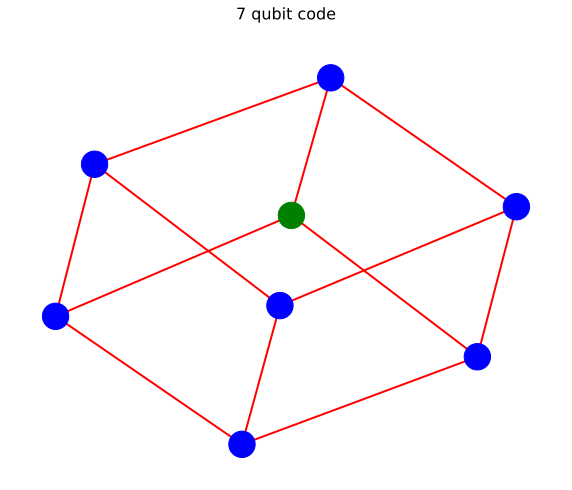

In [29]:
nxg = nx.Graph()
bounds = []
for v in d["vertices"]:
    v_type = v["t"]
    if v["id"] in d["inputs"]:
        color = "green"
    else:
        color = "blue"
    if v_type != VertexType.BOUNDARY:
        nxg.add_node(v["id"], 
                    color=color, 
                    title=f"Type: {v_type.name}")
    else:
        bounds.append(v["id"])
        
for e in d["edges"]:
    vertexes = d["vertices"]
    edge_type = e[2]
    edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
    if e[0] not in bounds and e[1] not in bounds:
        nxg.add_edge(e[0], e[1])
        nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=30)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
# nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

# Add title to the plot
plt.title("7 qubit code", fontsize=16, pad=20)

plt.axis('off')
plt.show()

net = Network(notebook=True, directed=False)
net.from_nx(nxg)
net.toggle_physics(True)

## Shor code

### Generate graph

In [32]:
pyzx_circ = Circuit.from_qasm(shor_code)
g = pyzx_circ.to_graph()
input_state = "0"*(8) + "/"*1
g.apply_state(input_state)
d = to_universal_graph_representation(g)

### Display graph

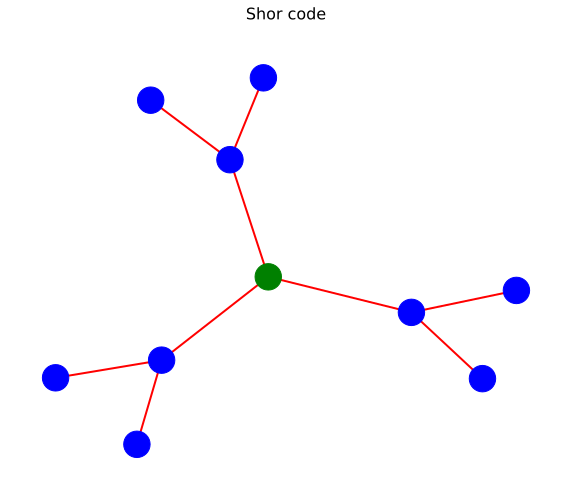

In [33]:
nxg = nx.Graph()
bounds = []
for v in d["vertices"]:
    v_type = v["t"]
    if v["id"] in d["inputs"]:
        color = "green"
    else:
        color = "blue"
    if v_type != VertexType.BOUNDARY:
        nxg.add_node(v["id"], 
                    color=color, 
                    title=f"Type: {v_type.name}")
    else:
        bounds.append(v["id"])
        
for e in d["edges"]:
    vertexes = d["vertices"]
    edge_type = e[2]
    edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
    if e[0] not in bounds and e[1] not in bounds:
        nxg.add_edge(e[0], e[1])
        nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=30)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
# nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

# Add title to the plot
plt.title("Shor code", fontsize=16, pad=20)

plt.axis('off')
plt.show()

net = Network(notebook=True, directed=False)
net.from_nx(nxg)
net.toggle_physics(True)

# Run benchmarks

## $n$ as variable

Run benchmark with random instances with the number of physical qubits ($n$) as variable 

In [ ]:
%run benchmarks/benchmark_universal.py --test_n --clean

Display the results

In [ ]:
%run benchmarks/plot.py --path "benchmarks/test_k" 

and in logarithmic scale

In [ ]:
%run benchmarks/plot.py --path "benchmarks/test_k" --log_scale

## $k$ as variable

Run benchmark with random instances with the number of logical qubits ($k$) as variable 

In [ ]:
%run benchmarks/benchmark_universal.py --test_k --clean

Display the results

In [ ]:
%run benchmarks/plot.py --path "benchmarks/test_k" 

and in logarithmic scale

In [ ]:
%run benchmarks/plot.py --path "benchmarks/test_k" --log_scale